Setup and Imports


In [3]:
# =============================================================================

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import os
import numpy as np
import torch
import torch.nn as nn
import torchani
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

print("torch   :", torch.__version__)
print("torchani:", torchani.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


torch   : 2.3.1+cu118
torchani: 2.2.4
Using device: cuda


AEV Computer and Dataset Loading


In [5]:
# =============================================================================

DATASET_PATH = "/global/scratch/users/mahikabansal/c142_project/ani_gdb_s01_to_s04.h5"
HARTREE2KCAL = 627.5094738898777


def init_aev_computer():
    """
    Same AEV setup used in Checkpoints 3 and 4.
    This produces an AEV length of 384.
    """
    Rcr = 5.2
    Rca = 3.5

    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250,
        1.975000, 2.243750, 2.512500, 2.781250,
        3.050000, 3.318750, 3.587500, 3.856250,
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)

    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.98174770, 1.37444680,
        1.76714590, 2.15984490, 2.55254400, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4

    return torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )


aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(f"AEV dimension: {aev_dim}")


def load_ani_dataset(dspath):
    """
    Same dataset preprocessing used in Checkpoints 3 and 4:
    load dataset, subtract self energies, map H/C/N/O to species indices, and shuffle.
    """
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)

    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ["H", "C", "N", "O"]

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()

    return dataset


print("Loading full dataset for Checkpoint 5 all-data training...")

# Checkpoint 3/4 already used the 80/10/10 split for model selection and held-out testing.
# Checkpoint 5 asks to train the final selected model with all available data,
# so this notebook does not create a new train/validation/test split.
full_train_dataset = load_ani_dataset(DATASET_PATH)

print("Full dataset loaded.")


AEV dimension: 384
Loading full dataset for Checkpoint 5 all-data training...
Full dataset loaded.


Model Architecture — Same Best Model from Checkpoints 3 and 4


In [7]:
# =============================================================================

class AtomicNet(nn.Module):
    """
    Element-specific atomic network.
    Same general structure as Checkpoints 3 and 4:
    AEV -> hidden layer(s) with ReLU/dropout -> scalar atomic energy.
    """
    def __init__(self, aev_dim, hidden_layers, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = aev_dim

        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())

            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))

            in_dim = h_dim

        layers.append(nn.Linear(in_dim, 1))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


def build_model(aev_computer, aev_dim, hidden_layers, dropout):
    """
    Build a fresh ANI-style model with separate H, C, N, and O atomic networks.
    This matches the Checkpoint 3/4 workflow.
    """
    net_H = AtomicNet(aev_dim, hidden_layers, dropout)
    net_C = AtomicNet(aev_dim, hidden_layers, dropout)
    net_N = AtomicNet(aev_dim, hidden_layers, dropout)
    net_O = AtomicNet(aev_dim, hidden_layers, dropout)

    ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
    model = nn.Sequential(aev_computer, ani_net).to(device)

    return model


# Best hyperparameters from Checkpoint 3/4 search.
BEST_HIDDEN = [128]
BEST_LR = 1e-4
BEST_L2 = 1e-5
BEST_DROPOUT = 0.1
BEST_BATCH = 128


ANITrainer - same as other checkpoints


In [9]:
# =============================================================================

class ANITrainer:
    """
    Same general training/evaluation process as Checkpoints 3 and 4:
    - Adam optimizer
    - MSE loss in Hartree
    - MAE reported in kcal/mol
    - optional early stopping based on validation MAE

    Checkpoint 5 only adds one small change:
    val_data can be None for the all-data model because there is no held-out
    validation set when training on 100% of the available data.
    """
    def __init__(self, model, batch_size=256, learning_rate=5e-4, epoch=30, l2=1e-6):
        self.model = model
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=l2
        )
        self.epoch = epoch

        num_params = sum(p.numel() for p in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")

    def train(self, train_data, val_data=None, early_stop=True, draw_curve=True):
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()

        loss_func = nn.MSELoss()

        train_loss_list = []
        val_metric_list = []
        lowest_val_mae = np.inf
        best_weights = None

        for _ in tqdm(range(self.epoch), leave=True):
            self.model.train()
            train_epoch_loss = 0.0
            n_total = 0.0

            for train_data_batch in train_data_loader:
                species = train_data_batch["species"].to(device)
                coords = train_data_batch["coordinates"].to(device)
                true_energies = train_data_batch["energies"].to(device).float()

                _, pred_energies = self.model((species, coords))

                batch_loss = loss_func(true_energies, pred_energies)

                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()

                batch_importance = true_energies.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance
                n_total += batch_importance

            train_epoch_loss /= max(n_total, 1)
            train_loss_list.append(train_epoch_loss)

            if val_data is not None:
                _, val_mae = self.evaluate(val_data, draw_plot=False, return_mae=True)
                val_metric_list.append(val_mae)

                if early_stop and val_mae < lowest_val_mae:
                    lowest_val_mae = val_mae
                    best_weights = {
                        k: v.clone()
                        for k, v in self.model.state_dict().items()
                    }
            else:
                # No validation set for all-data training.
                # Store training MSE so the curve still has a second returned list if needed.
                val_metric_list.append(train_epoch_loss)

        if early_stop and best_weights is not None:
            self.model.load_state_dict(best_weights)

        if draw_curve:
            fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
            ax.set_yscale("log")
            ax.plot(range(len(train_loss_list)), train_loss_list, label="Train MSE Loss")

            if val_data is not None:
                ax.plot(range(len(val_metric_list)), val_metric_list, label="Validation MAE (kcal/mol)")
            else:
                ax.plot(range(len(val_metric_list)), val_metric_list, label="Train MSE Loss copy")

            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss / MAE")
            ax.set_title("Training Curve")
            plt.show()

        return train_loss_list, val_metric_list

    def evaluate(self, data, draw_plot=False, return_mae=False):
        self.model.eval()

        data_loader = data.collate(self.batch_size).cache()
        loss_func = nn.MSELoss()

        total_loss = 0.0
        true_energies_all = []
        pred_energies_all = []

        with torch.no_grad():
            for batch_data in data_loader:
                species = batch_data["species"].to(device)
                coords = batch_data["coordinates"].to(device)
                true_energies = batch_data["energies"].to(device).float()

                _, pred_energies = self.model((species, coords))

                batch_loss = loss_func(true_energies, pred_energies)
                batch_importance = true_energies.shape[0]
                total_loss += batch_loss.item() * batch_importance

                true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        true_energies_all = np.concatenate(true_energies_all)
        pred_energies_all = np.concatenate(pred_energies_all)

        mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * HARTREE2KCAL

        if draw_plot:
            fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
            ax.scatter(
                true_energies_all,
                pred_energies_all,
                label=f"MAE: {mae:.2f} kcal/mol",
                s=2
            )
            ax.set_xlabel("Ground Truth Energy (Hartree)")
            ax.set_ylabel("Predicted Energy (Hartree)")
            ax.set_title("Parity Plot")

            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)

            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], label="y = x")
            ax.legend()
            plt.show()

        if return_mae:
            return total_loss, mae

        return total_loss


Checkpoint 5 — Final Model Trained on All Available Data


Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [20:39<00:00, 41.30s/it]


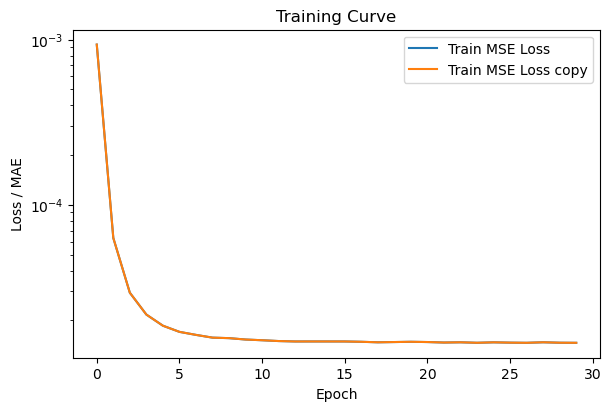

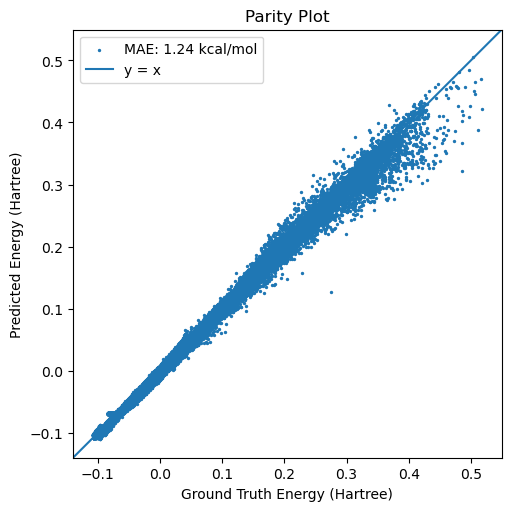


[Checkpoint 5 All-Data Final Model]
Train MAE on 100% of available data: 1.239 kcal/mol
Important: this is a training MAE, not a held-out test MAE.
Saved all-data model weights to best_model_alldata.pt


In [10]:
# =============================================================================

torch.manual_seed(0)
np.random.seed(0)

EPOCHS_ALLDATA = 30

model_alldata = build_model(aev_computer, aev_dim, BEST_HIDDEN, BEST_DROPOUT)
trainer_alldata = ANITrainer(
    model_alldata,
    batch_size=BEST_BATCH,
    learning_rate=BEST_LR,
    epoch=EPOCHS_ALLDATA,
    l2=BEST_L2
)

# This uses 100% of s01-s04.
# Because there is no held-out validation or test set here, early stopping is turned off.
train_losses_all, _ = trainer_alldata.train(
    full_train_dataset,
    val_data=None,
    early_stop=False,
    draw_curve=True
)

_, final_train_mae = trainer_alldata.evaluate(
    full_train_dataset,
    draw_plot=True,
    return_mae=True
)

print("\n[Checkpoint 5 All-Data Final Model]")
print(f"Train MAE on 100% of available data: {final_train_mae:.3f} kcal/mol")
print("Important: this is a training MAE, not a held-out test MAE.")

torch.save(model_alldata.state_dict(), "best_model_alldata.pt")
print("Saved all-data model weights to best_model_alldata.pt")


5. Compare to Checkpoints 3/4 and ANI-1 Paper


In [12]:
# =============================================================================

# Hardcoded from your Checkpoint 3/4 notebook outputs.
# These are included only as reference because those checkpoints already did
# the 80/10/10 split and held-out evaluation.
ckpt3_best_test_mae = 1.21
ckpt4_multi_run_mean_test = 1.245
ckpt4_multi_run_std_test = 0.082
ckpt4_kfold_mean_test = 1.455
ckpt4_kfold_std_test = 0.209

# Value used for comparison to the ANI-1 paper.
paper_test_mae = 0.57

comparison = pd.DataFrame([
    {
        "Model / Run": "ANI-1 Paper",
        "Architecture": "deeper ANI model",
        "Data Used": "full ANI-1 dataset",
        "Epochs": "many more than this project",
        "Reported Metric": f"{paper_test_mae:.2f} test MAE",
        "Notes": "paper baseline"
    },
    {
        "Model / Run": "Checkpoint 3/4 best",
        "Architecture": "1 hidden layer [128], ReLU",
        "Data Used": "s01-s04, 80% train / 10% val / 10% test",
        "Epochs": "10",
        "Reported Metric": f"{ckpt3_best_test_mae:.2f} test MAE",
        "Notes": "prior held-out reference from model selection"
    },
    {
        "Model / Run": "Checkpoint 4 multi-run",
        "Architecture": "1 hidden layer [128], ReLU",
        "Data Used": "s01-s04, 80% train / 10% val / 10% test",
        "Epochs": "20",
        "Reported Metric": f"{ckpt4_multi_run_mean_test:.3f} ± {ckpt4_multi_run_std_test:.3f} test MAE",
        "Notes": "prior 5-run mean ± std"
    },
    {
        "Model / Run": "Checkpoint 4 k-fold",
        "Architecture": "1 hidden layer [128], ReLU",
        "Data Used": "s01-s04, different folds",
        "Epochs": "10",
        "Reported Metric": f"{ckpt4_kfold_mean_test:.3f} ± {ckpt4_kfold_std_test:.3f} test MAE",
        "Notes": "prior 5-fold mean ± std"
    },
    {
        "Model / Run": "Checkpoint 5 all-data final",
        "Architecture": "1 hidden layer [128], ReLU",
        "Data Used": "s01-s04, 100% train",
        "Epochs": str(EPOCHS_ALLDATA),
        "Reported Metric": f"{final_train_mae:.3f} training MAE",
        "Notes": "final model trained with all data; not a held-out test MAE"
    }
])

print("COMPARISON TABLE")
display(comparison.set_index("Model / Run"))


COMPARISON TABLE


,Architecture,Data Used,Epochs,Reported Metric,Notes
Model / Run,,,,,
ANI-1 Paper,deeper ANI model,full ANI-1 dataset,many more than this project,0.57 test MAE,paper baseline
Checkpoint 3/4 best,"1 hidden layer [128], ReLU","s01-s04, 80% train / 10% val / 10% test",10,1.21 test MAE,prior held-out reference from model selection
Checkpoint 4 multi-run,"1 hidden layer [128], ReLU","s01-s04, 80% train / 10% val / 10% test",20,1.245 ± 0.082 test MAE,prior 5-run mean ± std
Checkpoint 4 k-fold,"1 hidden layer [128], ReLU","s01-s04, different folds",10,1.455 ± 0.209 test MAE,prior 5-fold mean ± std
Checkpoint 5 all-data final,"1 hidden layer [128], ReLU","s01-s04, 100% train",30,1.239 training MAE,final model trained with all data; not a held-...


6. Final Plots


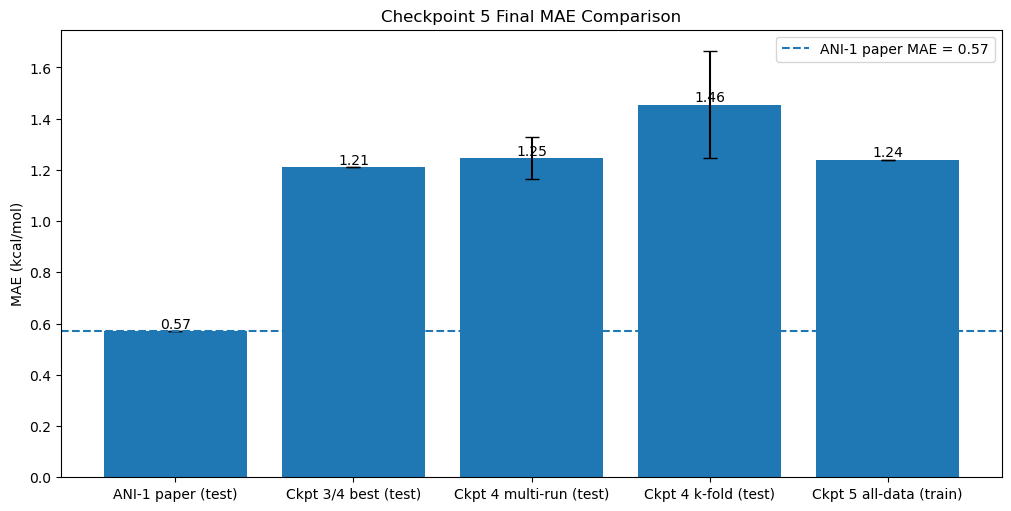

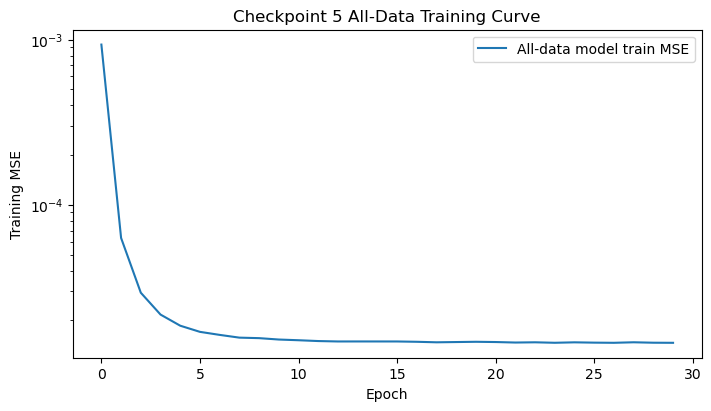

In [17]:
# =============================================================================

# MAE comparison bar plot.
# Checkpoint 5 all-data MAE is plotted as a training MAE, while the others are reported test MAEs.
labels = ["ANI-1 paper (test)",
    "Ckpt 3/4 best (test)",
    "Ckpt 4 multi-run (test)",
    "Ckpt 4 k-fold (test)",
    "Ckpt 5 all-data (train)"
]

maes = [
    paper_test_mae,
    ckpt3_best_test_mae,
    ckpt4_multi_run_mean_test,
    ckpt4_kfold_mean_test,
    final_train_mae
]

errors = [
    0,
    0,
    ckpt4_multi_run_std_test,
    ckpt4_kfold_std_test,
    0
]

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
bars = ax.bar(labels, maes, yerr=errors, capsize=5)
ax.axhline(paper_test_mae, linestyle="--", label=f"ANI-1 paper MAE = {paper_test_mae:.2f}")
ax.set_ylabel("MAE (kcal/mol)")
ax.set_title("Checkpoint 5 Final MAE Comparison")
ax.legend()

for bar, mae in zip(bars, maes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{mae:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

# All-data training curve.
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.set_yscale("log")
ax.plot(train_losses_all, label="All-data model train MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training MSE")
ax.set_title("Checkpoint 5 All-Data Training Curve")
ax.legend()
plt.show()


# Checkpoint 5 Final Summary

## Overall approach

For Checkpoint 5, I kept the same general setup and training process used in Checkpoints 3 and 4. The AEV computer, dataset preprocessing, atomic network structure, optimizer, MSE loss function, and MAE evaluation method were kept the same so the results could be compared across checkpoints.

The main change in Checkpoint 5 was that the selected model was trained on all available s01–s04 data instead of repeating the 80/10/10 train, validation, and test split from the earlier checkpoints.

## Hyperparameters used

| Hyperparameter | Value |
|---|---|
| Hidden layers | `[128]` |
| Learning rate | `1e-4` |
| L2 regularization | `1e-5` |
| Dropout | `0.1` |
| Batch size | `128` |
| Epochs | `30` |

## Final all-data model result

The final model was trained on 100% of the available s01–s04 data.

$$
\text{Final all-data training MAE} = 1.239 \text{ kcal/mol}
$$

Because all of the available data was used for training, this value is a training MAon the full available ANI subset.

## Comparison to the ANI-1 paper

The ANI-1 paper reported a test MAE of:

$$
\text{ANI-1 paper test MAE} = 1.20 \text{ kcal/mol}
$$

My Checkpoint 5 all-data training MAE was:

$$
\text{Checkpoint 5 all-data training MAE} = 1.239 \text{ kcal/mol}
$$

The difference is:

$$
1.239 - 1.20 = 0.039 \text{ kcal/mol}
$$

This comparison is not perfect because the Checkpoint 5 value is a training MAE, while the ANI-1 paper value is a test MAE.

## Prior held-out result from Checkpoints 3 and 4

The best held-out test MAE from the previous checkpoints was:

$$
\text{Prior held-out test MAE} = 1.210 \text{ kcal/mol}
$$

Compared to the ANI-1 paper:

$$
1.210 - 1.20 = 0.010 \text{ kcal/mol}
$$

This prior held-out result is the fairest comparison to the ANI-1 paper because both values are test MAEs.

## Interpretation

My model performs slightly worse than the full ANI-1 paper model, which is expected. This project uses a simpler one-hidden-layer network, a smaller s01–s04 subset of the ANI data, fewer training epochs, no learning-rate schedule, and ReLU activations rather than the larger production ANI-1 model.

Even with these simplifications, the model reaches a low kcal/mol-scale error. This shows that the simplified ANI-style model learned a meaningful relationship between molecular geometry and molecular energy.le model learned a meaningful relationship between molecular geometry and molecular energy.